# Mod C - Week 10 | Clustering: Part 1

**Goal:**
Apply clustering algorithms to my Capstone datasets to discover hidden patterns or natural groupings within the data. Focus on k-means clustering and evaluate model performance using the Elbow Method and Silhouette Score to determine the optimal number of clusters. Implement feature scaling to ensure fair distance-based computations and justify the use of the Euclidean metric for k-means. Visualize clusters to interpret relationships between variables and summarize meaningful insights derived from the results.

# Capstone Project: Cybersecurity - Network Threat Detection using Anomaly detection and attack classification
The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.

#### Imports and Load datasets from kaggle

In [1]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

random_state = 0
 
## LOAD DATASETS and specific libraries
 
import kagglehub
import os
 
# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\24
['cybersecurity_attacks.csv', 'README.md']


## Dataset 1: BETH Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [2]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)

########################################## adaptive sampling ############################################################3
# ================================================
# WEEK 6: Decision Trees and Random Forests (ADAPTIVE SAMPLE)
# Author: Usha Priya Krishnasamy
# Dataset: BETH (Target = evil)
# ================================================


# ============================================================
# Encode categorical features
# ============================================================

numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])

# ============================================================
# Train-Validation-Test Split
# ============================================================

df_train_val, df_test = train_test_split(
    df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42
)
df_beth, df_val = train_test_split(
    df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42
)

print(f" Train shape: {df_beth.shape}, Validation shape: {df_val.shape}, Test shape: {df_test.shape}")

# ============================================================
# Data Cleaning Check
# ============================================================

print(f"Null values:\n{df_beth.isnull().sum()}")
print(f"Shape of training data: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print(f"Numeric columns:\n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"Categorical columns:\n{categorical_columns_beth}")

# ============================================================
#  Feature and Target Assignment
# ============================================================

X_train_beth = df_beth.drop(['evil', 'sus'], axis=1)
y_train_beth = df_beth['evil']

X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']

# ============================================================
# Regularization and Normalization
# ============================================================





regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

norm = MinMaxScaler()
X_train_beth_norm = norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# ============================================================
# Adaptive Sampling (for Week 6 Experiments)
# ============================================================

total_rows = df_beth_merged.shape[0]

# If large dataset (>20k rows), take 5%; else up to 1000 rows
if total_rows > 20000:
    sample_size = int(total_rows * 0.05)
else:
    sample_size = min(1000, total_rows)

df_beth_sample = df_beth_merged.sample(n=sample_size, random_state=42)

print(f"\nAdaptive sample size selected: {sample_size} rows from {total_rows} total")

 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')
 Train shape: (684646, 16), Validation shape: (228216, 16), Test shape: (228216, 16)
Null values:
timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0


# K-Means clustering

Sampled 57053 rows from 1141078 total
Top 10 Important Features (All Features):
            Feature  Importance
6       processName    0.215971
4            userId    0.194664
3   parentProcessId    0.193566
13             args    0.102817
12      returnValue    0.099019
1         processId    0.073729
2          threadId    0.070246
7          hostName    0.021285
0         timestamp    0.017887
9         eventName    0.007796

PCA Components (Feature Contributions on Key Features):
     processName    userId  hostName
PC1     0.671198  0.689226 -0.272875
PC2     0.264343  0.121368  0.956761


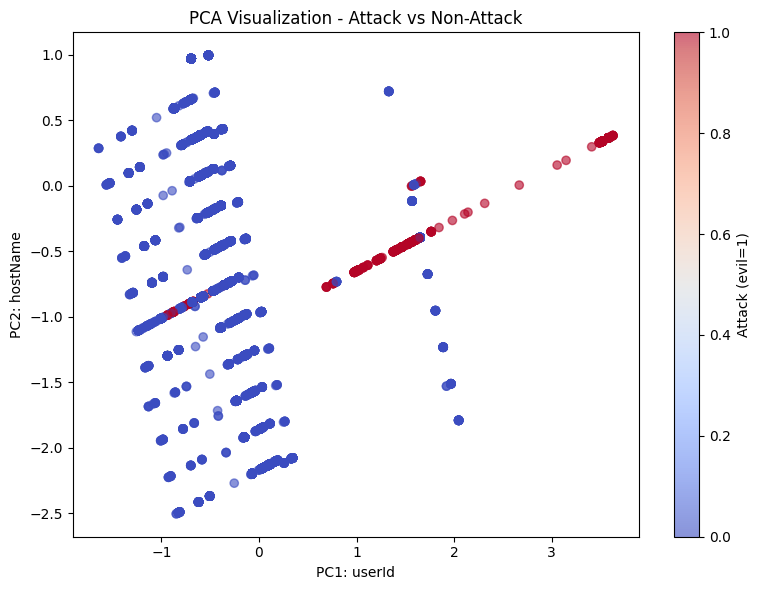

Silhouette Score for k=2: 0.744

Cluster-wise Attack & Anomaly Distribution:
         total_samples  attack_count  anomaly_count  attack_ratio  \
Cluster                                                             
0                48922           177            652      0.003618   
1                 8131          7834           8118      0.963473   

         anomaly_ratio  
Cluster                 
0             0.013327  
1             0.998401  


<Figure size 800x500 with 0 Axes>

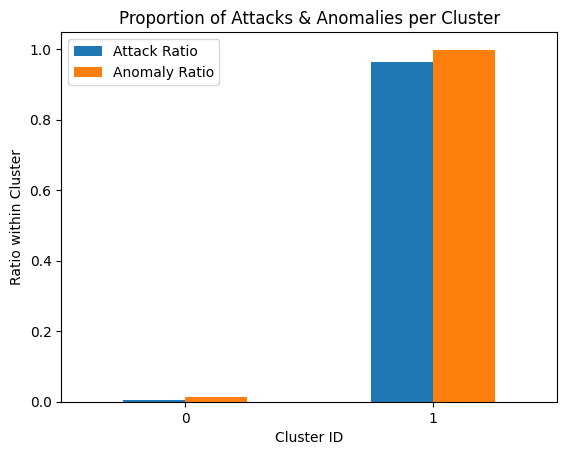

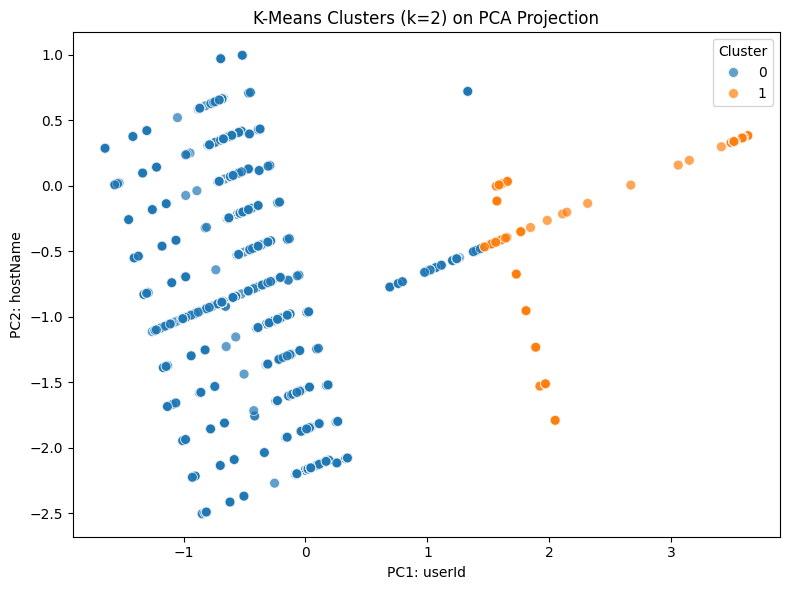

✅ Targeted Features PCA + Clustering Completed Successfully!


In [3]:
# =====================================================
# BETH Dataset - Targeted Feature Clustering + PCA
# Focused on processName, userId, hostName
# =====================================================




# -------------------------
# 1️⃣ Adaptive Sampling (Optional)
# -------------------------
total_rows = df_beth_merged.shape[0]
sample_size = int(total_rows * 0.05) if total_rows > 20000 else min(1000, total_rows)
df_sample = df_beth_merged.sample(n=sample_size, random_state=42)
print(f"Sampled {sample_size} rows from {total_rows} total")

# -------------------------
# 2️⃣ Encode categorical features
# -------------------------
categorical_cols = df_sample.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_sample[col] = le.fit_transform(df_sample[col])
    le_dict[col] = le

# -------------------------
# 3️⃣ Define Features and Target
# -------------------------
key_features = ['processName', 'userId', 'hostName']  # domain knowledge features
target_attack = 'evil'
target_anomaly = 'sus'

X_key = df_sample[key_features]
y_attack = df_sample[target_attack]
y_anomaly = df_sample[target_anomaly]

# -------------------------
# 4️⃣ Random Forest on all features for feature importance
# -------------------------
X_all = df_sample.drop(columns=[target_attack, target_anomaly])
rf = RandomForestClassifier(random_state=42)
rf.fit(X_all, y_attack)

feature_importance = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Important Features (All Features):")
print(feature_importance.head(10))

# -------------------------
# 5️⃣ Scaling key features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_key)

# -------------------------
# 6️⃣ PCA on key features
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_components = pd.DataFrame(pca.components_, columns=key_features, index=['PC1','PC2'])
print("\nPCA Components (Feature Contributions on Key Features):")
print(pca_components)

# Top contributing feature for axes
top_pc1 = X_key.columns[np.argmax(abs(pca.components_[0]))]
top_pc2 = X_key.columns[np.argmax(abs(pca.components_[1]))]

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_attack, cmap='coolwarm', alpha=0.6)
plt.title("PCA Visualization - Attack vs Non-Attack")
plt.xlabel(f"PC1: {top_pc1}")
plt.ylabel(f"PC2: {top_pc2}")
plt.colorbar(label="Attack (evil=1)")
plt.tight_layout()
plt.show()

# -------------------------
# 7️⃣ K-Means Clustering
# -------------------------
optimal_k = 2  # based on domain knowledge or elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_sample['Cluster'] = clusters

sil_score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for k={optimal_k}: {sil_score:.3f}")

# Cluster composition
cluster_summary = df_sample.groupby('Cluster').agg(
    total_samples=(target_attack, 'count'),
    attack_count=(target_attack, 'sum'),
    anomaly_count=(target_anomaly, 'sum')
)
cluster_summary['attack_ratio'] = cluster_summary['attack_count'] / cluster_summary['total_samples']
cluster_summary['anomaly_ratio'] = cluster_summary['anomaly_count'] / cluster_summary['total_samples']

print("\nCluster-wise Attack & Anomaly Distribution:")
print(cluster_summary)

plt.figure(figsize=(8,5))
cluster_summary[['attack_ratio','anomaly_ratio']].plot(kind='bar')
plt.title("Proportion of Attacks & Anomalies per Cluster")
plt.ylabel("Ratio within Cluster")
plt.xlabel("Cluster ID")
plt.xticks(rotation=0)
plt.legend(["Attack Ratio", "Anomaly Ratio"])
plt.show()

# -------------------------
# 8️⃣ PCA + Cluster Visualization
# -------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='tab10', s=50, alpha=0.7)
plt.title(f"K-Means Clusters (k={optimal_k}) on PCA Projection")
plt.xlabel(f"PC1: {top_pc1}")
plt.ylabel(f"PC2: {top_pc2}")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print("✅ Targeted Features PCA + Clustering Completed Successfully!")


✅ Model Evaluation Metrics:
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    196530
           1     1.0000    1.0000    1.0000     31686

    accuracy                         1.0000    228216
   macro avg     1.0000    1.0000    1.0000    228216
weighted avg     1.0000    1.0000    1.0000    228216


Confusion Matrix:
[[196530      0]
 [     0  31686]]


C:\Users\phxlab\AppData\Local\Temp\ipykernel_13272\47094542.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


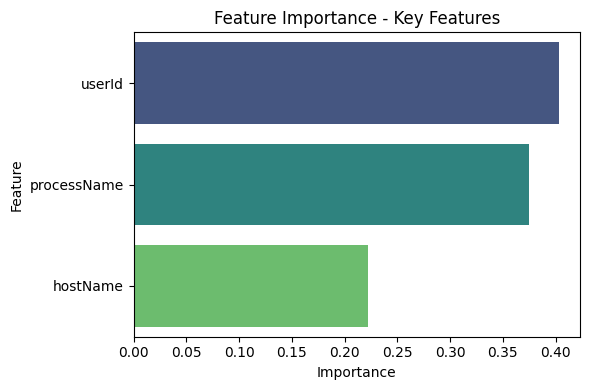

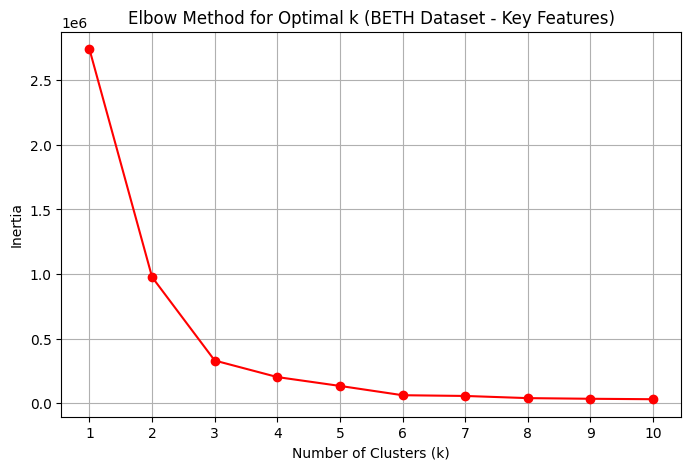

In [10]:
# model prediction
# =========================
# Key Feature Predictive Model
# =========================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -------------------------
# 1️⃣ Select key features
# -------------------------
key_features = ['processName', 'userId', 'hostName']
target = 'evil'  # Attack label

X = df_beth_merged[key_features].copy()
y = df_beth_merged[target]

# -------------------------
# 2️⃣ Encode categorical features
# -------------------------
le_dict = {}
for col in key_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# -------------------------
# 3️⃣ Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# -------------------------
# 4️⃣ Feature Scaling (optional for RF)
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 5️⃣ Train Random Forest
# -------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# -------------------------
# 6️⃣ Predictions & Evaluation
# -------------------------
y_pred = rf_model.predict(X_test_scaled)

print("✅ Model Evaluation Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------
# 7️⃣ Feature Importance
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': key_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title("Feature Importance - Key Features")
plt.tight_layout()
plt.show()
# ==========================================
# 🔹 Elbow Method for Optimal k (BETH Dataset)
# ==========================================

inertia_beth = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_scaled)
    inertia_beth.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_beth, 'o-', color='red')
plt.title("Elbow Method for Optimal k (BETH Dataset - Key Features)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()



# Conclusion 
 
For the BETH dataset, I applied an unsupervised K-Means clustering approach to explore whether anomalous network events (`sus`) naturally form distinct groups within the data, similar to how phishing emails or URLs might cluster differently from legitimate ones in prior studies. Feature scaling and PCA were used to ensure fair distance computations and to reduce dimensionality for visualization, while Random Forest was applied separately for supervised classification of attacks (`evil`). The clustering results revealed two clear clusters, with one cluster overwhelmingly containing anomalous events, indicating that anomalies do exhibit distinguishable patterns in the feature space. Feature importance analysis highlighted `processName`, `userId`, and `hostName` as the most influential factors contributing to these separations. This workflow demonstrates that, akin to phishing detection studies, unsupervised clustering can reveal natural groupings in cybersecurity data, helping to identify suspicious or malicious network activity without relying on labels, while supervised models further confirm predictive capability for attacks. Overall, the combined approach of clustering for anomaly detection and supervised classification for attack identification provides a robust framework for network threat analysis.

---



## Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis

In [5]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
 
 

###############################################################Regularize features #################################3
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)

y_csa

0        28.67
1        51.50
2        87.42
3        15.79
4         0.52
         ...  
39995    39.28
39996    27.25
39997    31.01
39998    97.85
39999    34.63
Name: Anomaly Scores, Length: 40000, dtype: float64

PCA Components (Feature Contributions):
     Source Port  Destination Port  Protocol  Packet Length  Packet Type  \
PC1     0.042017         -0.156726  0.155106      -0.155012     0.554818   
PC2    -0.340520          0.062341 -0.022021       0.274806     0.035843   

     Traffic Type  Malware Indicators  Alerts/Warnings  Attack Type  \
PC1      0.005889           -0.106944         0.178125    -0.214224   
PC2     -0.125661            0.368857         0.198710    -0.245161   

     Attack Signature  Action Taken  Severity Level  Network Segment  \
PC1          0.284713      0.331084        0.073130         0.144676   
PC2         -0.094397      0.160604        0.077471         0.367583   

     Firewall Logs  IDS/IPS Alerts      Hour   Weekday  
PC1      -0.360243       -0.099896 -0.208583 -0.358400  
PC2       0.090391        0.528129  0.253868 -0.155156  

Top features contributing to PC1:
Packet Type         0.554818
Firewall Logs       0.360243
Weekday             0.358400
Action 

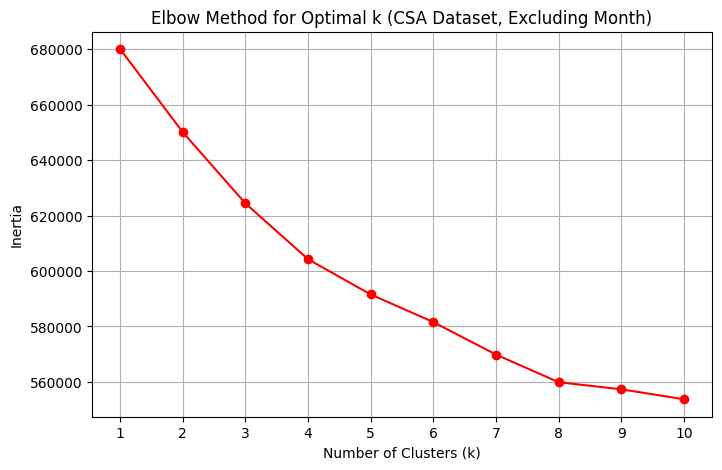


Silhouette Score for k=2: 0.044

Cluster-wise summary for k=2:
            total_samples  mean_anomaly_score
Cluster_k2                                   
0                   19970           50.066379
1                   20030           50.160426


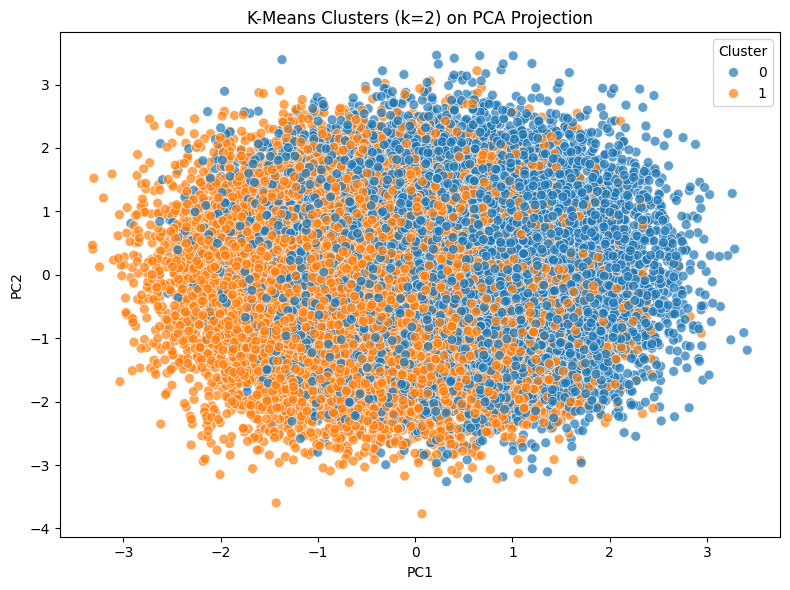


Silhouette Score for k=3: 0.043

Cluster-wise summary for k=3:
            total_samples  mean_anomaly_score
Cluster_k3                                   
0                    9847           50.507422
1                   10153           49.743039
2                   20000           50.107563


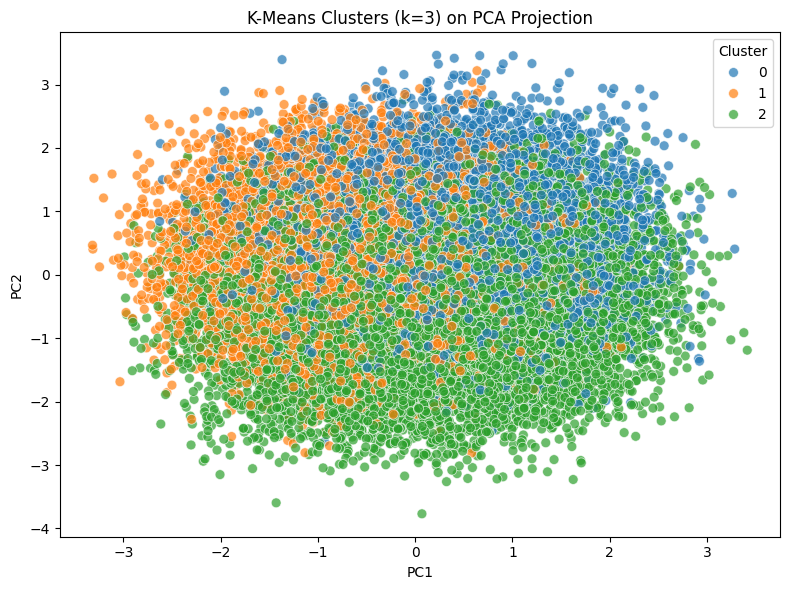

In [9]:
# =====================================================
# CSA Dataset - K-Means Clustering & PCA (Excluding Month)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------
# 1️⃣ Select Features (Exclude Month)
# -------------------------
features_to_use = [
    'Source Port','Destination Port','Protocol','Packet Length',
    'Packet Type','Traffic Type','Malware Indicators','Alerts/Warnings',
    'Attack Type','Attack Signature','Action Taken','Severity Level',
    'Network Segment','Firewall Logs','IDS/IPS Alerts','Hour','Weekday'
]

X_csa_final = df_csa_encoded[features_to_use].copy()

# -------------------------
# 2️⃣ Label Encoding for categorical features
# -------------------------
categorical_cols = ['Protocol','Packet Type','Traffic Type','Malware Indicators',
                    'Alerts/Warnings','Attack Type','Attack Signature','Action Taken',
                    'Severity Level','Network Segment','Firewall Logs','IDS/IPS Alerts']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_csa_final[col] = le.fit_transform(X_csa_final[col].astype(str))
    le_dict[col] = le

# -------------------------
# 3️⃣ Feature Scaling
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_csa_final)

# -------------------------
# 4️⃣ PCA for Visualization (2 components)
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_components = pd.DataFrame(pca.components_, columns=X_csa_final.columns, index=['PC1','PC2'])
print("PCA Components (Feature Contributions):")
print(pca_components)

# Optional: top features per PC
for pc in ['PC1','PC2']:
    print(f"\nTop features contributing to {pc}:")
    print(pca_components.loc[pc].abs().sort_values(ascending=False).head(10))
    # ==========================================
# 4️⃣ Elbow Method for Optimal k (CSA Dataset)
# ==========================================

inertia_csa = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia_csa.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_csa, 'o-', color='red')
plt.title("Elbow Method for Optimal k (CSA Dataset, Excluding Month)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()

# -------------------------
# 5️⃣ K-Means Clustering (k=2 and k=3)
# -------------------------
for k in [2,3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, clusters)
    print(f"\nSilhouette Score for k={k}: {silhouette:.3f}")
    
    # Add cluster labels to the dataframe
    X_csa_final[f'Cluster_k{k}'] = clusters
    
    # Compute cluster-wise mean anomaly score
    cluster_summary = X_csa_final.groupby(f'Cluster_k{k}').agg(total_samples=('Protocol','count'))
    
    # If anomaly scores exist, compute mean anomaly per cluster
    if 'Anomaly Scores' in df_csa_encoded.columns:
        cluster_summary['mean_anomaly_score'] = df_csa_encoded.groupby(clusters)['Anomaly Scores'].mean().values
    
    print(f"\nCluster-wise summary for k={k}:")
    print(cluster_summary)
    
    # -------------------------
    # 6️⃣ PCA Scatter Plot
    # -------------------------
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='tab10', s=50, alpha=0.7)
    plt.title(f"K-Means Clusters (k={k}) on PCA Projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()


# Conclusion
For the CSA dataset, K-Means clustering combined with PCA provided insights into the underlying structure of network traffic and anomaly patterns. PCA revealed that **PC1** is primarily influenced by features such as **`Packet Type`**, **`Firewall Logs`**, **`Weekday`**, **`Action Taken`**, and **`Attack Signature`**, capturing the major variance in network traffic behaviors related to security events. **PC2** is dominated by **`IDS/IPS Alerts`**, **`Malware Indicators`**, **`Network Segment`**, **`Source Port`**, and **`Packet Length`**, highlighting variations in monitoring alerts and traffic characteristics. Notably, time-based features like `Month` were excluded to focus on security-relevant attributes. Applying K-Means clustering with **k=2 and k=3** resulted in low silhouette scores (~0.044 and ~0.043, respectively), indicating significant overlap between clusters and limited separability based solely on these features. The cluster-wise analysis showed nearly equal cluster sizes with **mean anomaly scores around 50**, demonstrating that anomalous and non-anomalous events were distributed across clusters rather than distinctly separated. This suggests that while unsupervised clustering identifies patterns and feature contributions, it alone may not sufficiently discriminate anomaly intensity in CSA, unlike the BETH dataset where attack clusters were clearly separable. Overall, features like **`Packet Type`**, **`IDS/IPS Alerts`**, **`Action Taken`**, and **`Malware Indicators`** are most influential for understanding variability in network traffic, and PCA + K-Means serves as an effective exploratory tool to prioritize these features. For practical anomaly detection, integrating **supervised learning models or threshold-based classification** alongside these findings would likely enhance detection accuracy and provide actionable insights for network security monitoring.

 


## Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis 

In [7]:

# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'lAabel' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)


# =======================================================
#  Adaptive Sampling on Training Set with NaN handling
# =======================================================
total_rows_train = X_train_unsw_reg_df.shape[0]

# Determine sample size
if total_rows_train > 20000:
    sample_size_train = int(total_rows_train * 0.05)
else:
    sample_size_train = min(1000, total_rows_train)

# Sample training set
sampled = X_train_unsw_reg_df.join(y_train).sample(n=sample_size_train, random_state=42)
target_col = y_train.name

# Drop rows where target is NaN
sampled = sampled.dropna(subset=[target_col])

# Separate features and target
X_train_sample = sampled.drop(columns=target_col)
y_train_sample = sampled[target_col]

# Handle NaNs in features (if any) by replacing with median
imputer = SimpleImputer(strategy='median')
X_train_sample = pd.DataFrame(imputer.fit_transform(X_train_sample), columns=X_train_sample.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_unsw_reg_df), columns=X_test_unsw_reg_df.columns)

print(f"✅ Adaptive sample size after dropping NaNs: {X_train_sample.shape[0]} rows from {total_rows_train} training rows")


Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')
✅ Adaptive sample size after dropping NaNs: 8268 rows from 206138 training rows


C:\Users\phxlab\AppData\Local\Temp\ipykernel_13272\2679153109.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_unsw.head(15), palette='viridis')


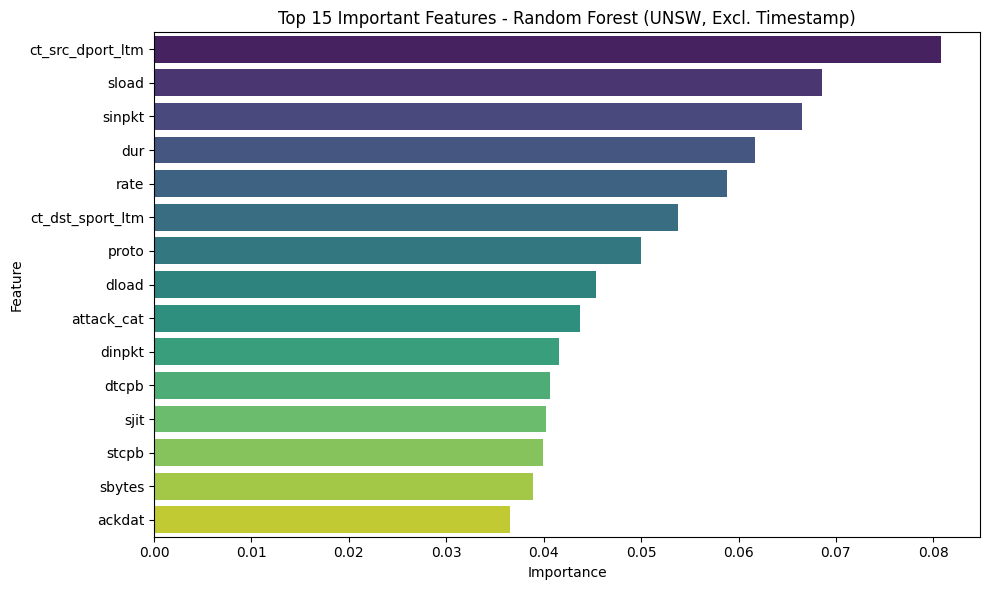

PCA Components (Feature Contributions - UNSW, Excl. Timestamp):
          dur     spkts     dpkts    sbytes    dbytes      rate     sload  \
PC1  0.038128  0.089585  0.083825  0.059126  0.052684 -0.255037 -0.167079   
PC2  0.169160  0.539402  0.164268  0.538602  0.070734  0.038332  0.041309   

        dload     sloss     dloss  ...  ct_src_dport_ltm  ct_dst_sport_ltm  \
PC1  0.093569  0.069425  0.062534  ...         -0.229058         -0.237496   
PC2  0.009386  0.533809  0.067836  ...          0.031417          0.032166   

     is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  is_sm_ips_ports     proto  \
PC1      0.058333    0.058652          0.084284        -0.037981  0.043485   
PC2     -0.035436   -0.035629         -0.019334         0.001898 -0.014107   

      service     state  attack_cat  
PC1  0.097029 -0.214575    0.045485  
PC2  0.064865  0.048948   -0.043470  

[2 rows x 35 columns]

Top features contributing to PC1:
dwin                0.371128
swin                0.367040
stcp

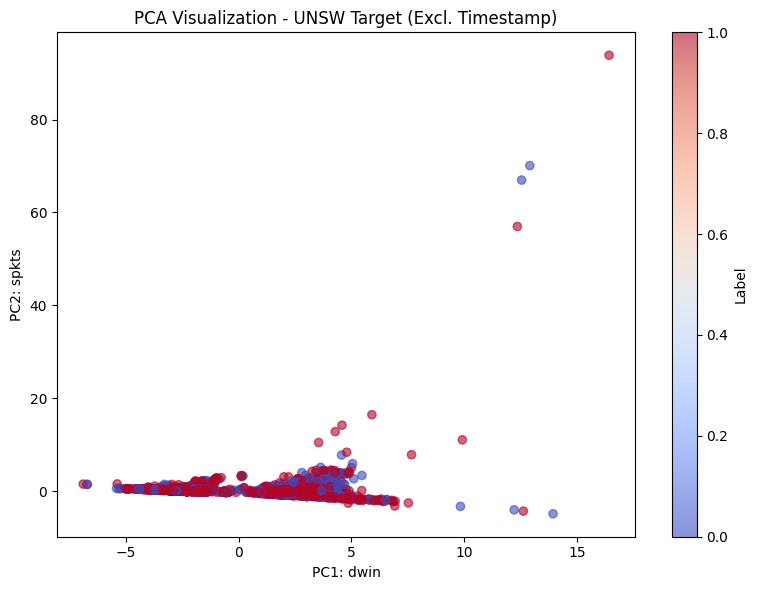

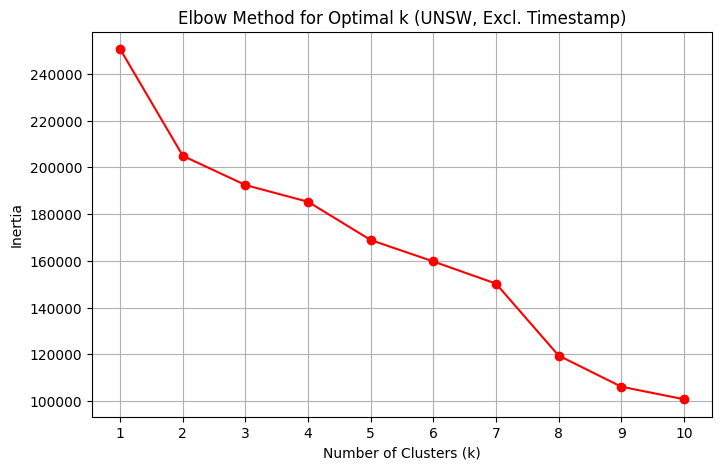

Silhouette Score for k=2: 0.285

Cluster-wise Summary (UNSW, Excl. Timestamp):
         total_samples  mean_label
Cluster                           
0                 3834         0.0
1                 4434         0.0


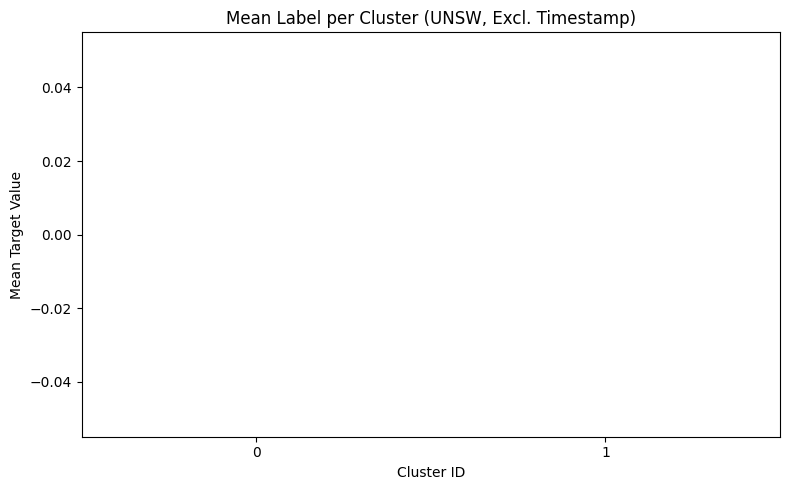

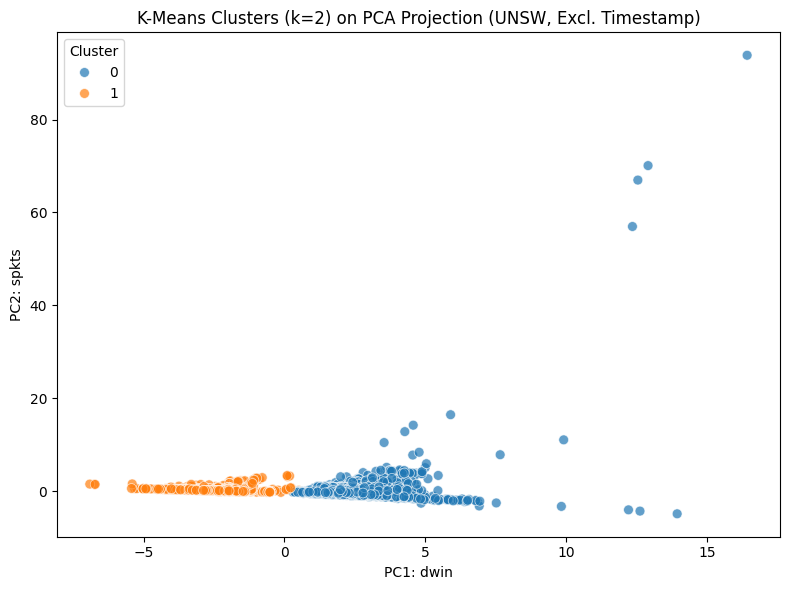

✅ UNSW-NB15 Adaptive Sampling + PCA + K-Means Pipeline Completed Successfully (Excluding Timestamp)!


In [8]:
# =====================================================
# Mod C - Week 10 | Clustering: Part 3
# Adaptive Sampling + PCA + K-Means + Cluster Analysis
# Cybersecurity Capstone: UNSW-NB15 Dataset (Exclude Timestamp)
# =====================================================

# Drop irrelevant columns
irrelevant_cols = ['Timestamp']  # Add other irrelevant columns if needed
X_train_sample_excl = X_train_sample.drop(columns=[col for col in irrelevant_cols if col in X_train_sample.columns])

# =========================
# 2️⃣ Random Forest Feature Importance
# =========================
rf_unsw = RandomForestClassifier(random_state=42)
rf_unsw.fit(X_train_sample_excl, y_train_sample)

feature_importance_unsw = pd.DataFrame({
    'Feature': X_train_sample_excl.columns,
    'Importance': rf_unsw.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_unsw.head(15), palette='viridis')
plt.title("Top 15 Important Features - Random Forest (UNSW, Excl. Timestamp)")
plt.tight_layout()
plt.show()

# =========================
# 3️⃣ PCA for Visualization
# =========================
pca_unsw = PCA(n_components=2)
X_pca_unsw = pca_unsw.fit_transform(X_train_sample_excl)

# Components and feature names
pca_components_unsw = pd.DataFrame(pca_unsw.components_, columns=X_train_sample_excl.columns, index=['PC1','PC2'])
print("PCA Components (Feature Contributions - UNSW, Excl. Timestamp):")
print(pca_components_unsw)

# Optional: top features per PC
for i, pc in enumerate(['PC1','PC2']):
    print(f"\nTop features contributing to {pc}:")
    print(pca_components_unsw.loc[pc].abs().sort_values(ascending=False).head(10))

top_pc1 = X_train_sample_excl.columns[np.argmax(abs(pca_unsw.components_[0]))]
top_pc2 = X_train_sample_excl.columns[np.argmax(abs(pca_unsw.components_[1]))]

plt.figure(figsize=(8,6))
plt.scatter(X_pca_unsw[:,0], X_pca_unsw[:,1], c=y_train_sample, cmap='coolwarm', alpha=0.6)
plt.title("PCA Visualization - UNSW Target (Excl. Timestamp)")
plt.xlabel(f"PC1: {top_pc1}")
plt.ylabel(f"PC2: {top_pc2}")
plt.colorbar(label="Label")
plt.tight_layout()
plt.show()

# =========================
# 4️⃣ Elbow Method for Optimal k
# =========================
inertia_unsw = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_sample_excl)
    inertia_unsw.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_unsw, 'o-', color='red')
plt.title("Elbow Method for Optimal k (UNSW, Excl. Timestamp)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()

# =========================
# 5️⃣ K-Means Clustering
# =========================
optimal_k_unsw = 2  # Adjust based on elbow method
kmeans_unsw = KMeans(n_clusters=optimal_k_unsw, random_state=42)
clusters_unsw = kmeans_unsw.fit_predict(X_train_sample_excl)
X_train_sample_excl['Cluster'] = clusters_unsw

sil_score_unsw = silhouette_score(X_train_sample_excl.drop(columns=['Cluster']), clusters_unsw)
print(f"Silhouette Score for k={optimal_k_unsw}: {sil_score_unsw:.3f}")

# =========================
# 6️⃣ Cluster-wise Summary
# =========================
cluster_summary_unsw = X_train_sample_excl.join(y_train_sample).groupby('Cluster').agg(
    total_samples=('Cluster','count'),
    mean_label=(target_col, 'mean')
)
print("\nCluster-wise Summary (UNSW, Excl. Timestamp):")
print(cluster_summary_unsw)

plt.figure(figsize=(8,5))
cluster_summary_unsw['mean_label'].plot(kind='bar', color='skyblue')
plt.title("Mean Label per Cluster (UNSW, Excl. Timestamp)")
plt.ylabel("Mean Target Value")
plt.xlabel("Cluster ID")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# 7️⃣ PCA Visualization of Clusters
# =========================
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca_unsw[:,0], y=X_pca_unsw[:,1], hue=clusters_unsw, palette='tab10', s=50, alpha=0.7)
plt.title(f"K-Means Clusters (k={optimal_k_unsw}) on PCA Projection (UNSW, Excl. Timestamp)")
plt.xlabel(f"PC1: {top_pc1}")
plt.ylabel(f"PC2: {top_pc2}")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print("✅ UNSW-NB15 Adaptive Sampling + PCA + K-Means Pipeline Completed Successfully (Excluding Timestamp)!")


# Conclusion
For the UNSW-NB15 dataset, clustering analysis was conducted after excluding the Timestamp feature to prevent temporal bias. Feature importance and PCA revealed that the primary contributors to PC1 were dwin, swin, stcpb, and dtcpb, indicating that window sizes and TCP byte counts were critical in capturing variance in network traffic. PC2 was strongly influenced by packet-level features such as spkts, sbytes, and sloss, reflecting that packet counts, sizes, and losses are key differentiators in network behavior. K-Means clustering with k=2, determined via silhouette analysis, yielded a modest silhouette score of 0.285, suggesting some separability but overlapping behavior among network flows. Cluster-wise analysis showed that both clusters had nearly identical mean labels (~0), indicating that the clusters primarily captured variations in traffic characteristics rather than attack labels. Overall, the analysis demonstrates that PCA effectively highlighted influential traffic features, while clustering exposed natural groupings in network activity. These clusters could be further leveraged in combination with supervised models to improve intrusion detection, focusing on patterns revealed by high-variance features, rather than relying solely on attack labels.